In [1]:
from bids import BIDSLayout
import nibabel as nb
import numpy as np
from nilearn.interfaces.fmriprep import load_confounds
from nilearn.image import load_img

### Load data

In [ ]:
db = BIDSLayout(root="/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/", database_path='/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/bids_layout/')

tmp_files = db.get(
        task='twostep',
        suffix="events",
        extension="tsv",
        return_type="filename"
    )

participants = [i.split('/')[-4].split('-')[-1] for i in tmp_files]

space_name = "MNI152NLin2009cAsym"
#TODO other tasks
task = 'risksensitive'


def get_subject_data(pidx):
    """
    Loads bids compliant fMRI data for a single subject.

    Input:
        subject-id
    
    Returns:
        dictionary containing subject data

    """

    d = {}

    events_files = db.get(
        task=task,
        suffix="events",
        extension="tsv",
        return_type="filename",
        subject=participants[pidx]
    )

    d["event_files"] = events_files

    bold_files = db.get(
        task=task,
        suffix="bold",
        space=space_name,
        extension="nii.gz",
        return_type="filename",
        res="02",
        subject=participants[pidx]
    )

    # mask = db.get(
    #     task=task,
    #     suffix="mask",
    #     space=space_name,
    #     extension="nii.gz",
    #     return_type="filename",
    #     res="02",
    #     subject=participants[pidx]
    # )

    d["bold_files"] = bold_files

    tr=db.get(
        task=task,
        suffix="bold",
        space=space_name,
        extension="nii.gz",
        res="02",
        subject=participants[pidx]
    )[0].get_metadata()['RepetitionTime']

    d["tr"] = tr

    n_frames = nb.load(bold_files[0]).shape[-1]
    frame_times = np.arange(n_frames) * tr + tr /2

    d["n_frames"] = n_frames
    d["frame_times"] = frame_times

    d["confounds"] = load_confounds(bold_files, strategy=("motion", "wm_csf"))[0]

    return d

subject = get_subject_data(0)
img = load_img(subject["bold_files"][0])


## LSS

In [ ]:
from tqdm import tqdm
from pprint import pprint
import pandas as pd
from nilearn.image import load_img
from nilearn.glm.first_level import FirstLevelModel
import os
#import gc

output_dir = os.path.join(os.path.curdir, "lss_maps", task)




def lss_transformer(events, row_number):
    events = events.copy()

    #events with nan duration are of len 0
    events.loc[pd.isna(events["duration"]), "duration"] = 0

    reward_events = events[events["event_type"] == "reward"]
    y = reward_events["reward"]
    reward_events = reward_events[["onset", "duration"]].reset_index(drop=True)
    reward_events["trial_type"] = "reward"

    trial_name = f"reward_{row_number:03d}"

    reward_events.loc[row_number, "trial_type"] = trial_name


    return reward_events, trial_name, y    


    

def extract_betas_lss(subject, id):

    glm_parameters = {
        "t_r": subject["tr"],
        "hrf_model": "spm",
        "drift_model": "cosine",
        "noise_model": "ar1",
        "high_pass": 0.008, 
        "smoothing_fwhm": 6,
        "n_jobs": -1,
        "slice_time_ref": 0.5,
    }


    events = pd.read_table(subject["event_files"][0])
    n_trials = len(events[events["event_type"] == "reward"])
    fmri_file = nb.load(subject["bold_files"][0]) #for some reason this makes shit crahs lol

    # Loop through the trials of interest and transform the DataFrame for LSS
    rewards = []


    for i_trial in tqdm(range(n_trials)):
        lss_events_df, trial_condition, reward = lss_transformer(events, i_trial)


        # Compute and collect beta maps
        lss_glm = FirstLevelModel(**glm_parameters)
        lss_glm.fit(fmri_file, lss_events_df, confounds=subject["confounds"])
        return
    
        beta_map = lss_glm.compute_contrast(
            trial_condition,
            output_type="effect_size",
        )

        save_maps(beta_map, lss_glm.design_matrices_[0], id, i_trial)
        rewards.append(reward)
    
    # del beta_map, lss_glm, lss_events_df
    # gc.collect()

    # save rewards
    sub_dir = os.path.join(output_dir, f"sub-{id:03d}")

    rewards_file = os.path.join(sub_dir, f"y_values_sub-{id:03d}.csv")

    # Convert to a DataFrame for clarity and easy loading later
    pd.DataFrame(rewards, columns=["reward"]).to_csv(rewards_file, index=False)
    
def save_maps(map, dm, subject_id, trial):
    sub_dir = os.path.join(output_dir, f"sub-{subject_id:03d}")
    beta_file = os.path.join(sub_dir, f"beta_map_trial-{trial:03d}.nii.gz")
    if not os.path.exists(sub_dir):
        os.mkdir(sub_dir)

    nb.save(map, beta_file)

    dm_file = os.path.join(sub_dir, f"des_mat_trial-{trial:03d}.csv")
    dm.to_csv(dm_file)
    

for idx in range(len(participants)):
    subject = get_subject_data(idx)
    extract_betas_lss(subject, idx)

  0%|          | 0/179 [00:00<?, ?it/s]

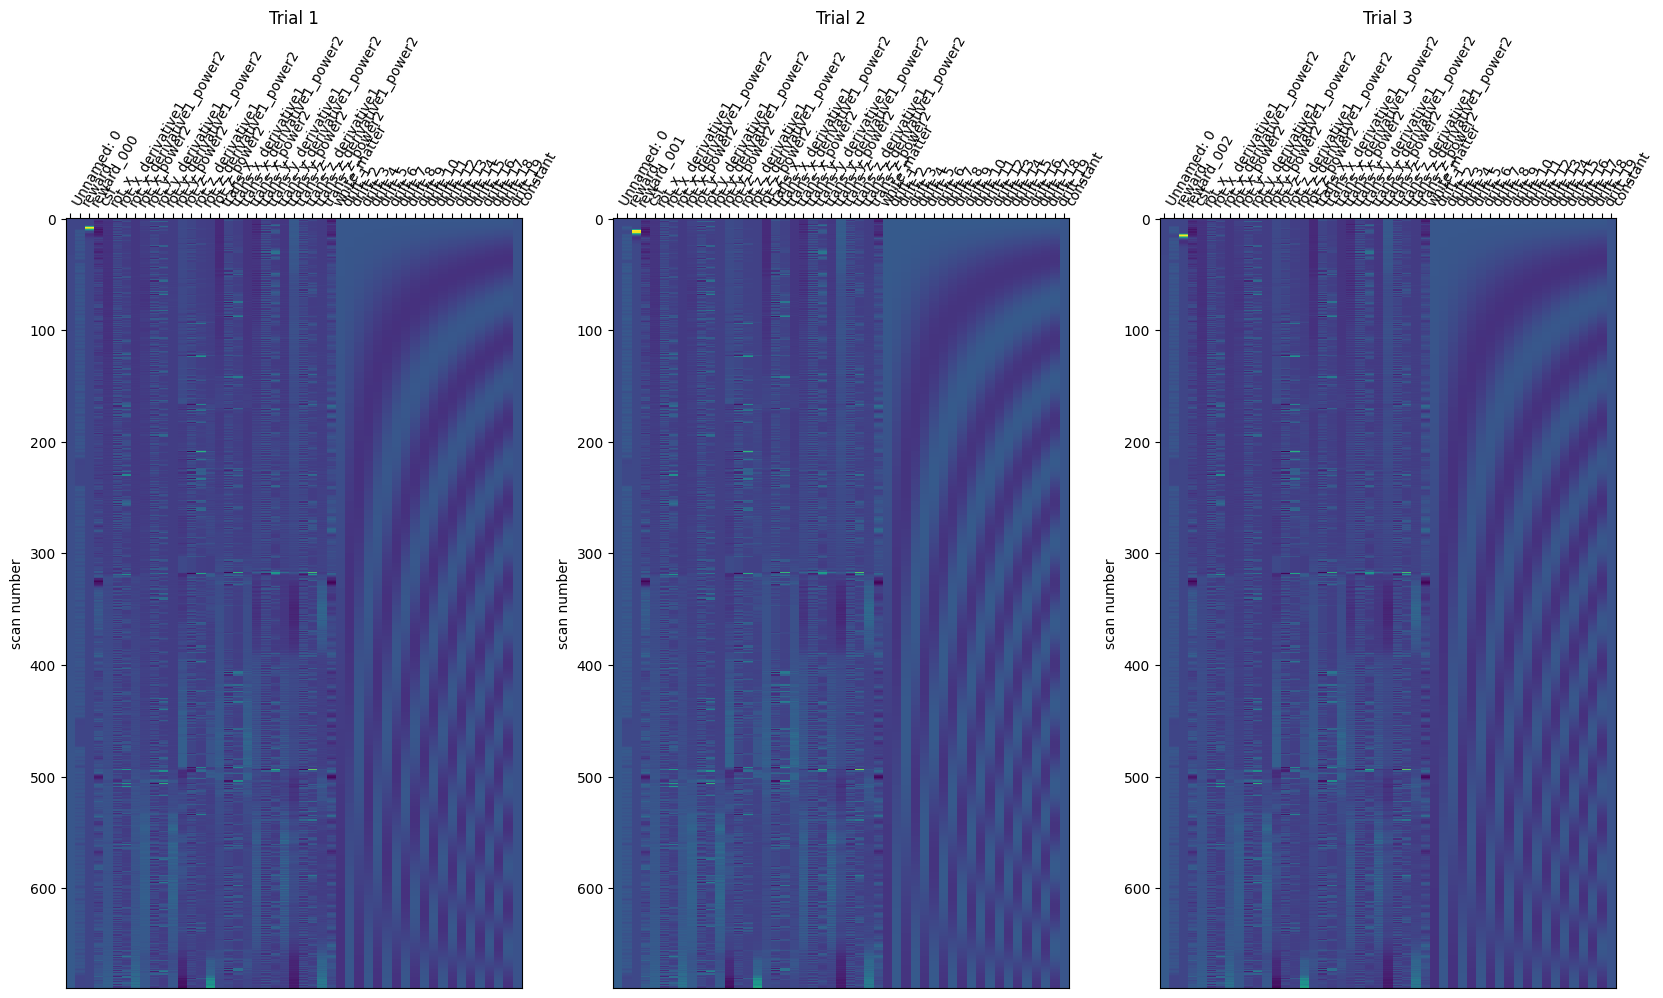

In [ ]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix


des_mats = [pd.read_csv(f"./lss_maps/sub-0/des_mat_sub-0_trial-{i}.csv") for i in range(3)]

fig, axes = plt.subplots(ncols=3, figsize=(20, 10))
for i_trial in range(3):
    plot_design_matrix(
        des_mats[i_trial],
        axes=axes[i_trial],
    )
    axes[i_trial].set_title(f"Trial {i_trial + 1}")

## LSA

100%|██████████| 179/179 [00:32<00:00,  5.54it/s]


<Axes: label='conditions', ylabel='scan number'>

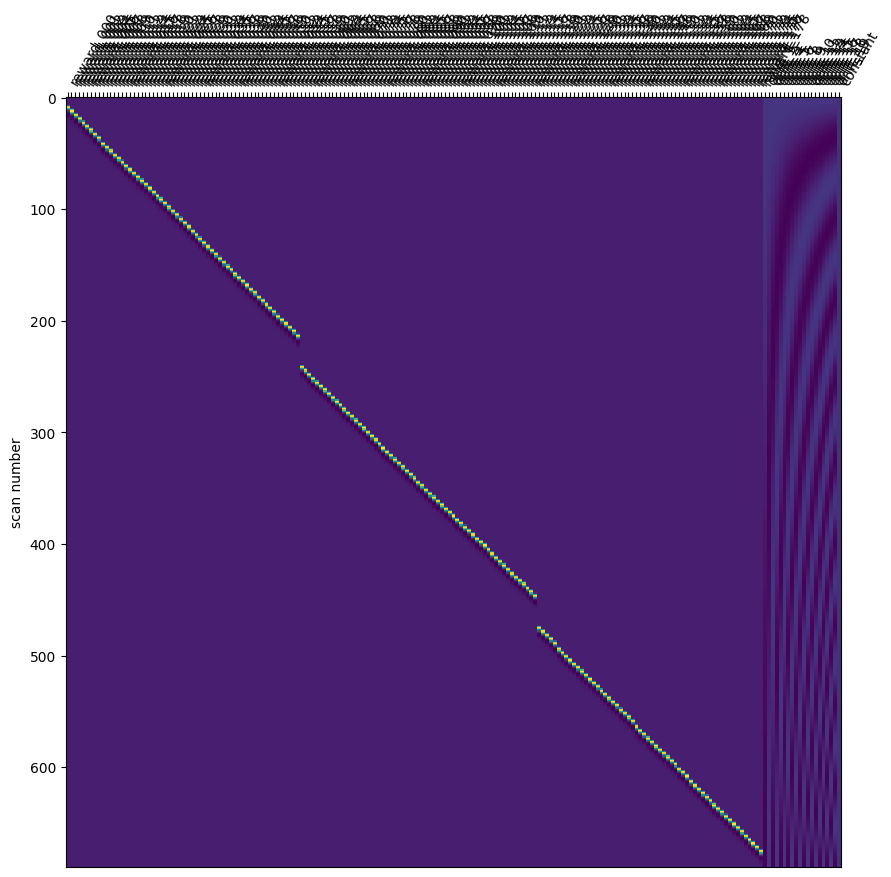

In [ ]:
def lsa_transformer(events):
    
    events = events.copy()

    #events with nan duration are of len 0
    events.loc[pd.isna(events["duration"]), "duration"] = 0

    reward_events = events[events["event_type"] == "reward"]
    y = reward_events["reward"]
    reward_events = reward_events[["onset", "duration"]].reset_index(drop=True)
    reward_events["trial_type"] = "reward"

    n_trials = len(reward_events)

    for row_number in range(n_trials):
        trial_name = f"reward_{row_number:03d}"

        reward_events.loc[row_number, "trial_type"] = trial_name

    return reward_events, y

def extract_betas_lsa(subject):

    events = pd.read_table(subject["event_files"][0])
    fmri_file = load_img(subject["bold_files"])

    lsa_events_df, y = lsa_transformer(events)

    lsa_glm = FirstLevelModel(**glm_parameters)
    lsa_glm.fit(fmri_file, lsa_events_df, confounds=subject["confounds"])

    dm = lsa_glm.design_matrices_[0]

    lsa_beta_maps = []
    trialwise_conditions = lsa_events_df["trial_type"].unique()

    for condition in tqdm(trialwise_conditions):
        beta_map = lsa_glm.compute_contrast(condition, output_type="effect_size")
        # Drop the trial number from the condition name to get the original name
        #condition_name = condition.split("_")[0]
        lsa_beta_maps.append(beta_map)

    lsa_beta_maps = concat_imgs(lsa_beta_maps)

    return lsa_beta_maps, dm, y

betas, dm, y = extract_betas_lsa(subject_data[0])

fig, ax = plt.subplots(figsize=(10, 10))
plot_design_matrix(dm, axes=ax)

## Masking

In [ ]:
from nilearn.image import concat_imgs
from nilearn.masking import apply_mask

imgs = [nb.load(f"./lss_maps/sub-0/beta_maps_sub-0_trial-{trial}.nii.gz") for trial in range(179)]
imgs = concat_imgs(imgs)
mask_p = "/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/masks/tpl-MNI152NLin2009cAsym_res-02_desc-brain_mask.nii.gz"
masked_data = apply_mask(imgs=imgs, mask_img=mask_p)
masked_data.shape
#shape = trials (time) x voxels

(179, 235840)

## Predictive model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = masked_data
Y = pd.read_csv("./lss_maps/sub-0/rewards_sub-0.csv")

column_name = Y.columns[0]
Y.drop(column_name, axis=1).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, Y)
pca = PCA()

scaler = StandardScaler()

pipe = Pipeline(steps=[("scaler", scaler), ("pca", pca)])

print(X_train.shape)
X_after = pipe.fit_transform(X_train)

array([[40.,  0.,  0., ..., 20., 20., 20.],
       [40.,  0.,  0., ..., 20., 20., 20.],
       [40.,  0.,  0., ..., 20., 20., 20.],
       ...,
       [40.,  0.,  0., ..., 20., 20., 20.],
       [40.,  0.,  0., ..., 20., 20., 20.],
       [40.,  0.,  0., ..., 20., 20., 20.]])

[['reward' 40.0 0.0 ... 20.0 20.0 20.0]
 ['reward' 40.0 0.0 ... 20.0 20.0 20.0]
 ['reward' 40.0 0.0 ... 20.0 20.0 20.0]
 ...
 ['reward' 40.0 0.0 ... 20.0 20.0 20.0]
 ['reward' 40.0 0.0 ... 20.0 20.0 20.0]
 ['reward' 40.0 0.0 ... 20.0 20.0 20.0]]


134
134


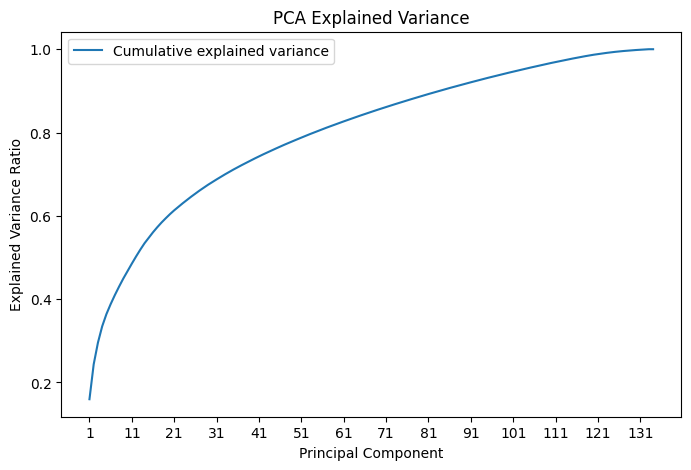

In [ ]:
explained_variance = pca.explained_variance_ratio_
print(len(pca.components_))
print(len(explained_variance))

# 4. Plot explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum(), label='Cumulative explained variance')

plt.title('PCA Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(np.arange(1, len(explained_variance), 10))
plt.legend()